# Shape Detection 
by Eske based on persistence silhouette. 

Idea: 

0) set environment 
1) get pointclouds
2) create persistence diagrams using ripserer 
3) create persistence silhuettes 
4) concatenate them 
5) use kmeans clustering on persistence silhuettes 

To save memory step 2 and 3 are joined in a single step 

## 0) Set environment 


In [1]:
# activate packages set environment 
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.activate(".")
# include src files 
include("src/filtration.jl")
import .Filtration
include("src/preprocessing.jl")
import .Preprocessing
include("src/visualization.jl")
import .Visualization
include("src/persistence.jl")
import .Persistence
# add packages 
using Clustering
using StatsPlots
using LinearAlgebra

  Activating project at `c:\Users\Lukas\Desktop\TopologicalDataAnalysis\ShapeDetectionGit\Detecting-Shapes`
  0 dependencies successfully precompiled in 52 seconds. 282 already precompiled.
  1 dependency errored.
  For a report of the errors see `julia> err`. To retry use `pkg> precompile`
  Activating project at `c:\Users\Lukas\Desktop\TopologicalDataAnalysis\ShapeDetectionGit\Detecting-Shapes`


## 1) Get pointclouds 

In [2]:
# Which pointclouds 
shapes = ["circle", "sphere", "torus", "line_segment", "disk", "potato", "ellipsoid"]
path_changes = Dict("line_segment" => "line")
n_pershape = [1,12,23,24,29] 
n_datapoints = 100
good_layout = (3,2)

pointclouds = []
corr_results = []
for s in shapes 
    for i in n_pershape
        push!(corr_results, s*"_"*lpad(i,4,'0'))
        # load the data 
        if s in keys(path_changes) 
            path = "data\\"*s*"\\samples\\"*path_changes[s]*"_"*lpad(i,4,'0')*".csv"
        else 
            path = "data\\"*s*"\\samples\\"*s*"_"*lpad(i,4,'0')*".csv"
        end 
        println(path)
        df = Preprocessing.load_pointcloud_csv(path)
        if n_datapoints != "end"
            df = df[1:n_datapoints,:]
        end 
        points = [tuple(df[i, :]...) for i in axes(df, 1)]
        push!(pointclouds, points)
    end 
end 

data\circle\samples\circle_0001.csv
data\circle\samples\circle_0012.csv
data\circle\samples\circle_0023.csv
data\circle\samples\circle_0024.csv
data\circle\samples\circle_0029.csv
data\sphere\samples\sphere_0001.csv
data\sphere\samples\sphere_0012.csv
data\sphere\samples\sphere_0023.csv
data\sphere\samples\sphere_0024.csv
data\sphere\samples\sphere_0029.csv
data\torus\samples\torus_0001.csv
data\torus\samples\torus_0012.csv
data\torus\samples\torus_0023.csv
data\torus\samples\torus_0024.csv
data\torus\samples\torus_0029.csv
data\line_segment\samples\line_0001.csv
data\line_segment\samples\line_0012.csv
data\line_segment\samples\line_0023.csv
data\line_segment\samples\line_0024.csv
data\line_segment\samples\line_0029.csv
data\disk\samples\disk_0001.csv
data\disk\samples\disk_0012.csv
data\disk\samples\disk_0023.csv
data\disk\samples\disk_0024.csv
data\disk\samples\disk_0029.csv
data\potato\samples\potato_0001.csv
data\potato\samples\potato_0012.csv
data\potato\samples\potato_0023.csv
da

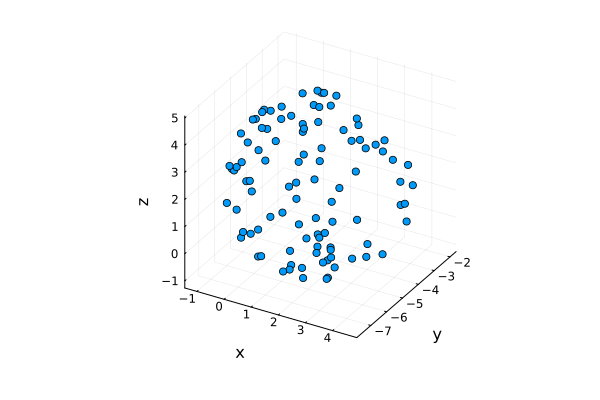

In [4]:
# visualize point cloud 
name = "potato_0001"
if !(name in corr_results)
    println("change the name to a loaded pointlcoud")
    println("- possible shapes: ", shapes)
    println("- possible numbers: ", n_pershape)
    println("name should be shape_00xx with xx changed to number")
else 
    idx = findfirst( ==("potato_0001"), corr_results)
    display(Visualization.plot_pointcloud_3d(pointclouds[8], check_npoints = false))
end 

## 2&3)  Persistence diagrams and Silhuette

In [7]:
silhouettes_separatly = Persistence.create_diagram_silhoutte(pointclouds)

Pointcloud No. 1
Pointcloud No. 2
Pointcloud No. 3
Pointcloud No. 4
Pointcloud No. 5
Pointcloud No. 6
Pointcloud No. 7
Pointcloud No. 8
Pointcloud No. 9
Pointcloud No. 10
Pointcloud No. 11
Pointcloud No. 12
Pointcloud No. 13
Pointcloud No. 14
Pointcloud No. 15
Pointcloud No. 16
Pointcloud No. 17
Pointcloud No. 18
Pointcloud No. 19
Pointcloud No. 20
Pointcloud No. 21
Pointcloud No. 22
Pointcloud No. 23
Pointcloud No. 24
Pointcloud No. 25
Pointcloud No. 26
Pointcloud No. 27
Pointcloud No. 28
Pointcloud No. 29
Pointcloud No. 30
Pointcloud No. 31
Pointcloud No. 32
Pointcloud No. 33
Pointcloud No. 34
Pointcloud No. 35


35-element Vector{Any}:
 Any[[0.0, 0.009206631484165947, 0.018370680508948814, 0.027443880905844032, 0.03612274029480532, 0.04395489725719959, 0.051170968049015754, 0.05756531428502335, 0.06318592293368869, 0.06857277472924202  …  0.003927011837738969, 0.0034906771891013073, 0.0030543425404636415, 0.0026180078918259806, 0.0021816732431883144, 0.0017453385945506536, 0.0013090039459129877, 0.0008726692972753268, 0.0004363346486376608, 0.0], [0.0, 0.0405514081753946, 0.0811028163507892, 0.12165422452618402, 0.16220563270157862, 0.20275704087697322, 0.24330844905236781, 0.2838598572277624, 0.32441126540315723, 0.36496267357855183  …  0.3649626735785514, 0.3244112654031568, 0.2838598572277622, 0.2433084490523676, 0.202757040876973, 0.1622056327015784, 0.1216542245261838, 0.0811028163507892, 0.0405514081753946, 0.0], [0.0, 0.00036243949815116056, 0.0007248789963023211, 0.001131485878548799, 0.0016835052436838535, 0.002235524608818908, 0.002787543973953963, 0.0033395633390892955, 0.0039125044

## 4) Concatenate the Silhuettes

To be able to change the weights without recomputing the diagrams this step is not combined with the step before

In [10]:
weights = (1,1,1)
silhouettes = [Persistence.concatenate_silhouette(s, weights) for s in silhouettes_separatly] 

35-element Vector{Vector{Any}}:
 [0.0, 0.009206631484165947, 0.018370680508948814, 0.027443880905844032, 0.03612274029480532, 0.04395489725719959, 0.051170968049015754, 0.05756531428502335, 0.06318592293368869, 0.06857277472924202  …  0.003261955483360811, 0.0028995159852096505, 0.00253707648705849, 0.0021746369889071465, 0.0018121974907559857, 0.0014497579926048252, 0.0010873184944536645, 0.0007248789963023211, 0.00036243949815116056, 0.0]
 [0.0, 0.006901040488470417, 0.013787894422789701, 0.02056157154964366, 0.027213214627106453, 0.033646155011362304, 0.03966492155631448, 0.04511831076453558, 0.05041478790482347, 0.05524514892832741  …  0.00580304854067685, 0.005067123871578883, 0.004331199202480916, 0.0035952745333825754, 0.002859349864284608, 0.002123425195186268, 0.0013875005260883004, 0.0007606863717716735, 0.00038034318588574067, 0.0]
 [0.0, 0.007597220280896382, 0.015169124644062126, 0.02270313826640681, 0.030024668518409247, 0.03695409013144321, 0.043328413034747555, 0.049120

### Plot the persistence silhouettes


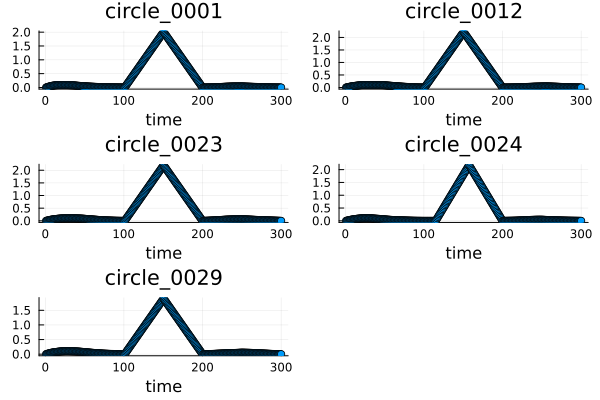

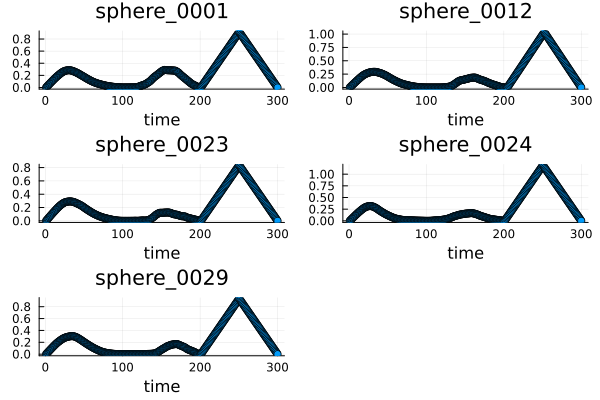

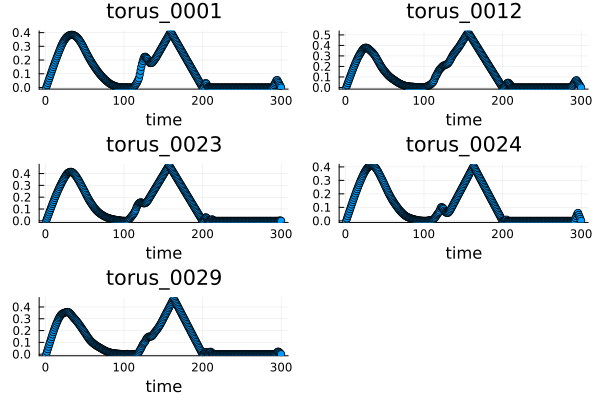

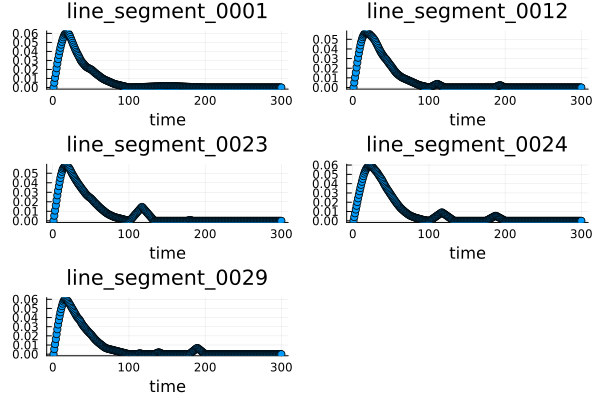

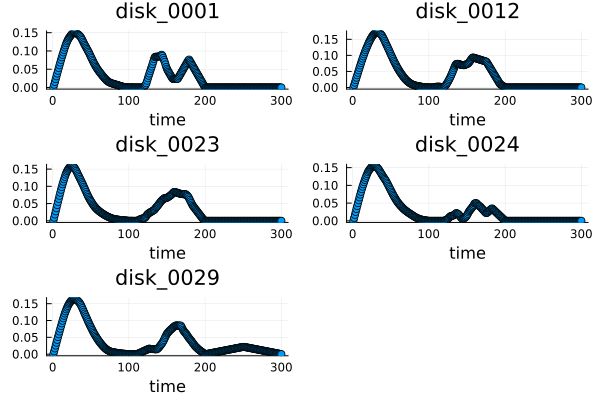

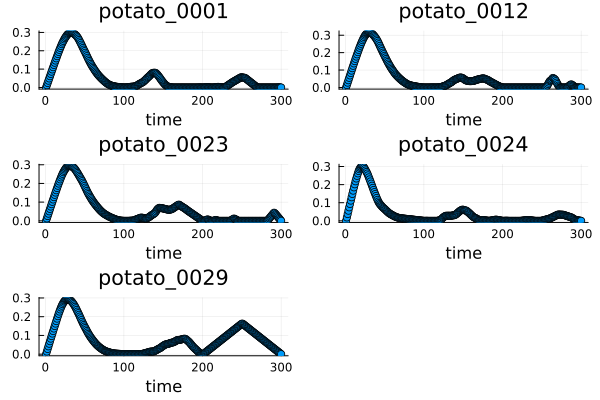

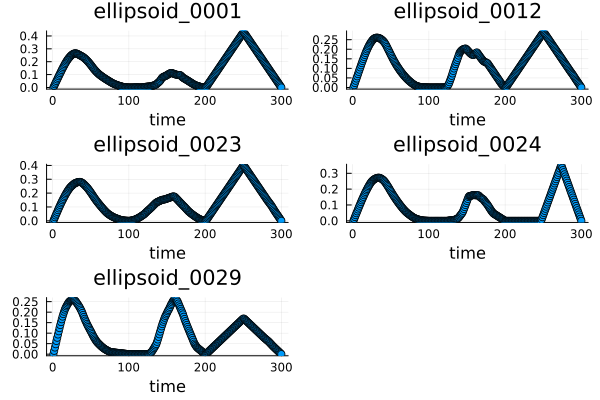

In [11]:
plots = []

for (i,sil) in enumerate(silhouettes) 
    ttl = corr_results[i]
    push!(plots,Visualization.plot_persistence_silhouette_approx(sil; ttl = ttl))
    if i%length(n_pershape) == 0
        display(plot(plots[(i-length(n_pershape)+1):i]..., layout = good_layout))
    end
end 

## 4) Clustering

In [56]:
X = [Vector{Float64}(s) for s in silhouettes]
X = hcat(X...)
for i in 1:size(X)[2]
    # normalize each col
    if norm(X[:,i]) != 0
        X[:,i] = X[:,i] ./ norm(X[:,i])
    end 
end 
res_clus_sil = kmeans(X, length(shapes))
clusters_sil = res_clus_sil.assignments
for cluster_idx in unique(clusters_sil)
    println("Cluster ",cluster_idx,"---------")
    println(corr_results[clusters_sil .== cluster_idx])
end

Cluster 3---------
Any["circle_0001", "circle_0012", "circle_0023", "circle_0024", "circle_0029"]
Cluster 2---------
Any["sphere_0001", "sphere_0012", "sphere_0023", "sphere_0024", "sphere_0029", "ellipsoid_0001", "ellipsoid_0012", "ellipsoid_0023"]
Cluster 6---------
Any["torus_0001", "torus_0023", "torus_0024", "disk_0001", "disk_0012"]
Cluster 1---------
Any["torus_0012", "torus_0029", "disk_0023", "disk_0029", "ellipsoid_0029"]
Cluster 5---------
Any["line_segment_0001", "line_segment_0012", "line_segment_0023", "line_segment_0024", "line_segment_0029", "potato_0024"]
Cluster 4---------
Any["disk_0024", "potato_0001", "potato_0012", "potato_0023", "potato_0029"]
Cluster 7---------
Any["ellipsoid_0024"]


### Plot centers of clusters together with the different items in cluster

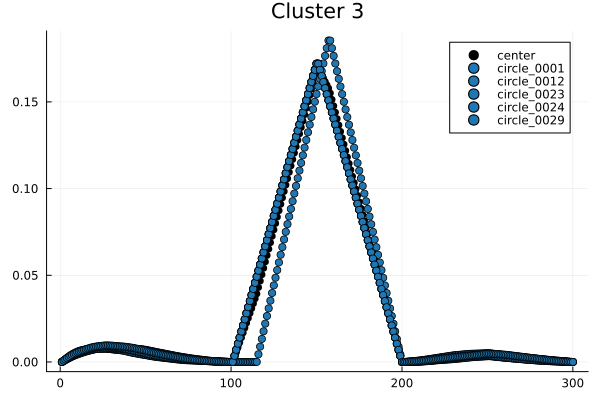

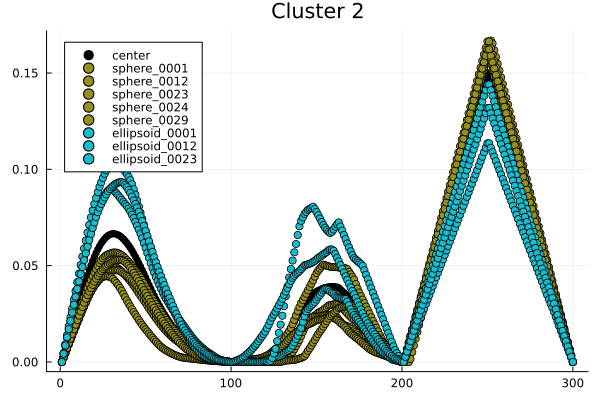

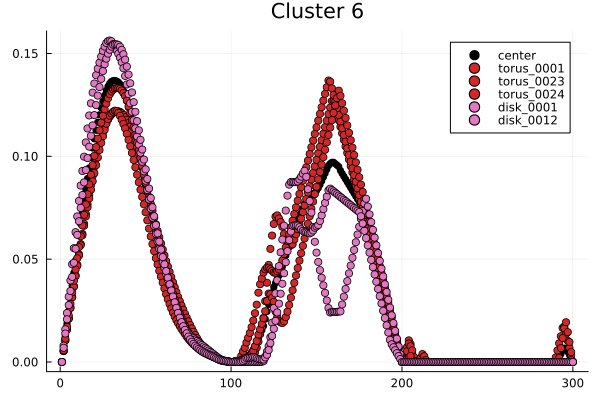

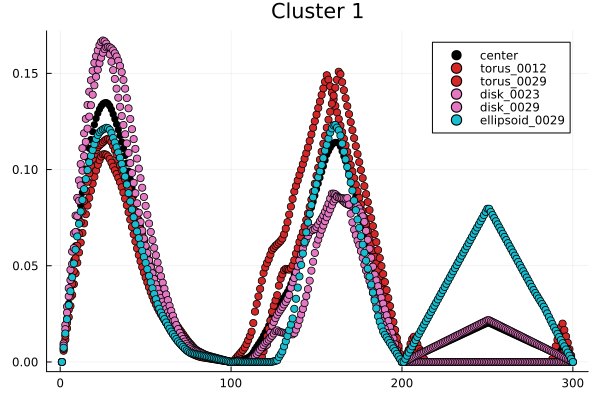

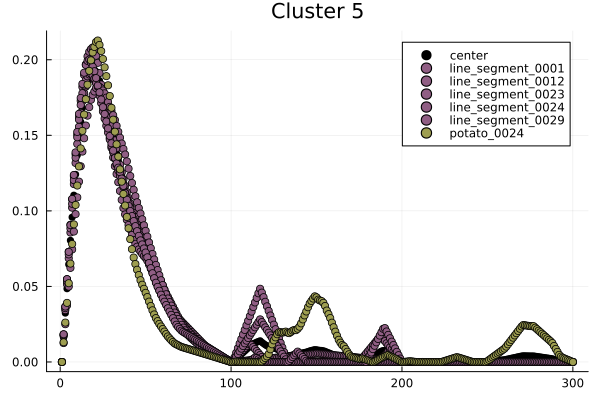

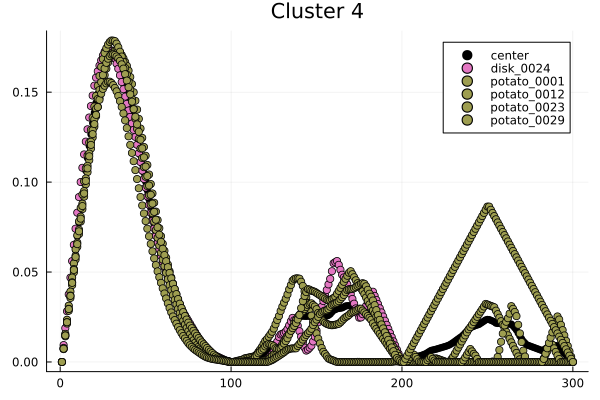

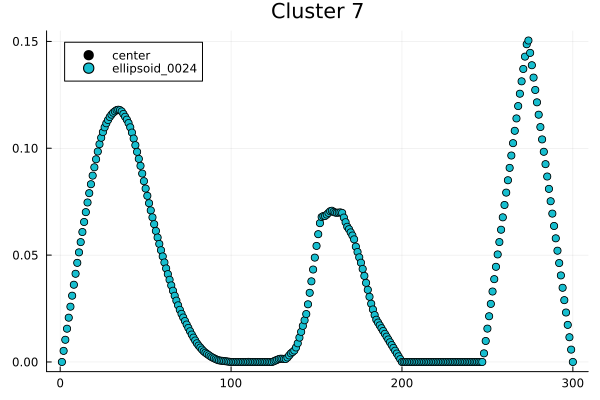

In [57]:
# set colors 
# should every shape has a own color or every pointcloud 
every_shape = true 
shape_colors = palette(:tab10, length(shapes)) 

plots_centers = [scatter(1:length(res_clus_sil.centers[:,cluster]), res_clus_sil.centers[:,cluster]; color = "black", label = "center", title = "Cluster " * string(cluster)) for cluster in unique(clusters_sil)]
for (idx_pc,pc) in enumerate(corr_results)
    # cluster 
    cluster_idx = findfirst( ==(clusters_sil[idx_pc]), unique(clusters_sil))

    if every_shape
        # shape of the pointcloud
        sp = join(split(pc, "_")[1:end-1], "_")
        # get index of the shape in shapes 
        idx_sp =  findfirst( ==(sp), shapes)
        # take X due to normalization! 
        scatter!(plots_centers[cluster_idx],1:length(silhouettes[idx_pc]), X[:,idx_pc]; label = pc, color = shape_colors[idx_sp])
    else 
        scatter!(plots_centers[cluster_idx],1:length(silhouettes[idx_pc]), X[:,idx_pc]; label = pc)
    end
end 

for pl in plots_centers 
    display(pl)
end 